# Assignment 1 – Titanic Survival Prediction


## Problem Statement




Perform exploratory data analysis, clean missing values, engineer simple features, train both Logistic Regression and Random Forest models, compare their performance, and explain which model you would deploy






## Dataset Description

The Titanic dataset contains information about passengers who traveled on the RMS Titanic. Each record represents one passenger and includes demographic details, ticket information, travel class, and survival status.

The dataset contains **891 passenger records** with **12 attributes**, including the target variable **Survived**. The objective is to predict whether a passenger survived the disaster using the available features.

**Dataset Used:** `titanic.csv`

## Dataset Attributes

| Attribute | Description |
|-----------|-------------|
| PassengerId | Unique identifier for each passenger |
| Survived | Survival status (0 = Did not survive, 1 = Survived) |
| Pclass | Passenger ticket class (1 = First, 2 = Second, 3 = Third) |
| Name | Passenger's full name |
| Sex | Gender of the passenger |
| Age | Age of the passenger in years |
| SibSp | Number of siblings or spouses aboard |
| Parch | Number of parents or children aboard |
| Ticket | Ticket number |
| Fare | Ticket fare paid by the passenger |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

In [1]:
#import the required libs

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Dataset Shape:", df.shape)


Dataset Shape: (891, 12)


In [6]:
# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()


Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Here we can see that theere are missing values in the columns : age,cabin

In [7]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Check missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


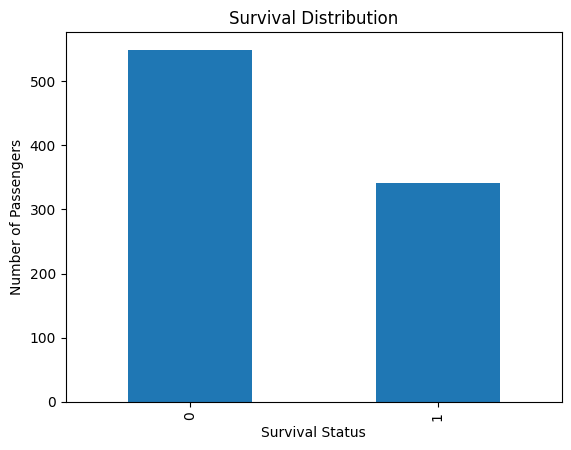

In [9]:
# Survival distribution
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

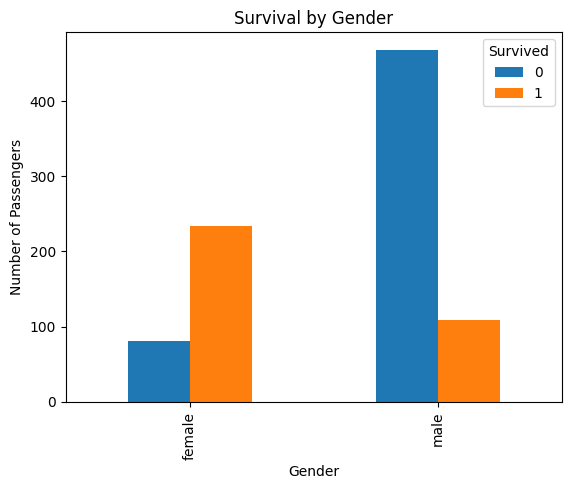

In [10]:
#now seeing the survival distribtuion by gender

pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

The graph shows that a higher proportion of **female passengers survived**, while most **male passengers did not survive**. This suggests that gender had a significant influence on survival.

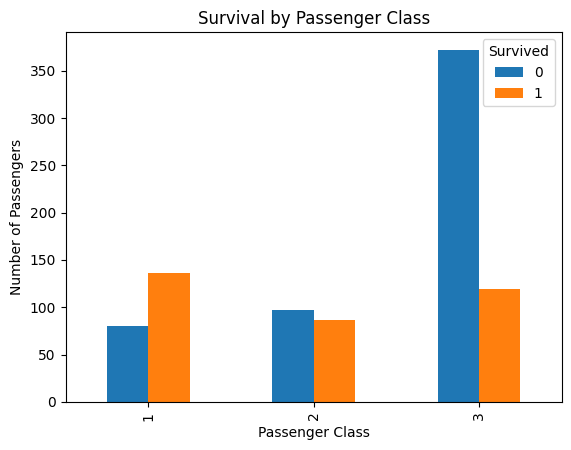

In [15]:
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

#here we can see that higher the class, higher the prob of survival while most deaths occured in the lowest class

In [11]:
#Fill missing values in Age with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values in Embarked with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column because it contains too many missing values
df.drop("Cabin", axis=1, inplace=True)

# Check if missing values are removed
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
# Create a new feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Display the first five rows
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


Here we have combined the cols sib, parent t ogather with the count of the individual to get the total family size

In [14]:
# Convert categorical variables into numerical values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1


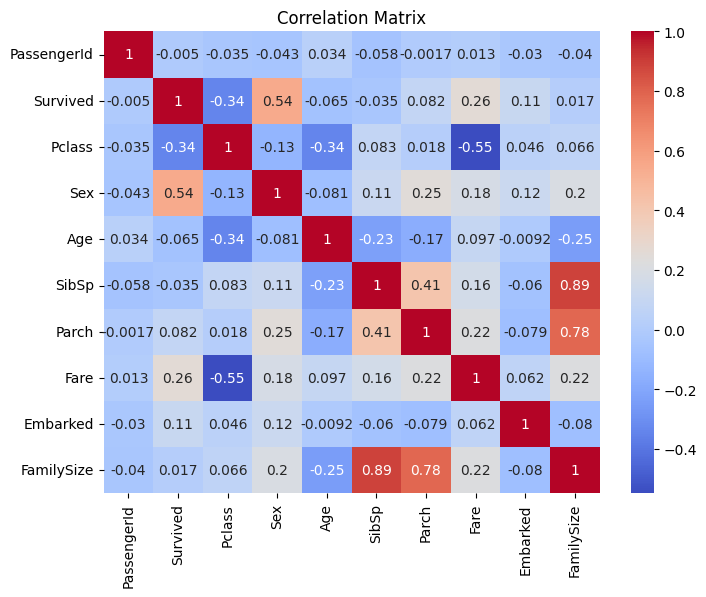

In [17]:
import seaborn as sns

#Correlation Analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Inference

- **Sex** has the highest positive correlation with **Survived (0.54)**, indicating that gender had the strongest influence on passenger survival.
- **Pclass (-0.34)** has a moderate negative correlation with survival, suggesting that passengers in higher classes were more likely to survive.
- **Fare (0.26)** shows a positive correlation with survival, indicating that passengers who paid higher fares had better survival chances.
- **PassengerId (-0.005)** has almost no correlation with survival, making it an unimportant feature for prediction.
- Most of the remaining features have weak correlations with survival, indicating that multiple features together may be required for accurate prediction.

In [18]:
#Select Features and Target

X = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize"
]]

# Select target
y = df["Survived"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (891, 8)
Target Shape  : (891,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 712
Testing Samples  : 179


In [21]:
#Train Logistic Regression Model

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [22]:
#Train Random Forest Model

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [24]:
#making predictions
# Logistic Regression predictions
lr_pred = lr_model.predict(X_test)

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

In [25]:
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy,4))
print("Random Forest Accuracy       :", round(rf_accuracy,4))

Logistic Regression Accuracy : 0.7989
Random Forest Accuracy       : 0.8212


In [26]:
print("Logistic Regression Classification Report\n")
print(classification_report(y_test, lr_pred))

print("\n----------------------------------------\n")

print("Random Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


----------------------------------------

Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



The **Random Forest** model achieved a higher testing accuracy (**82.12%**) compared to **Logistic Regression (79.89%)**. It also achieved better precision, recall, and F1-score for both survival classes. Therefore, the **Random Forest model** is selected for deployment because it provides more accurate and reliable predictions for passenger survival.

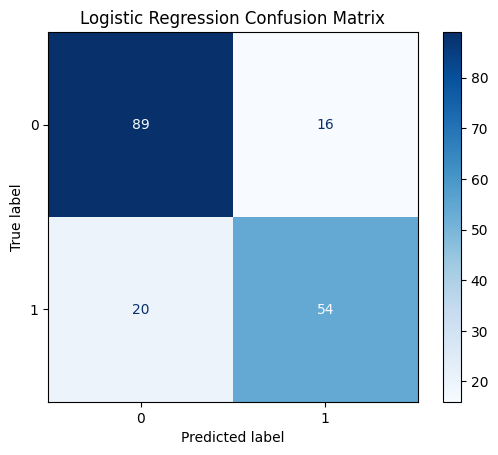

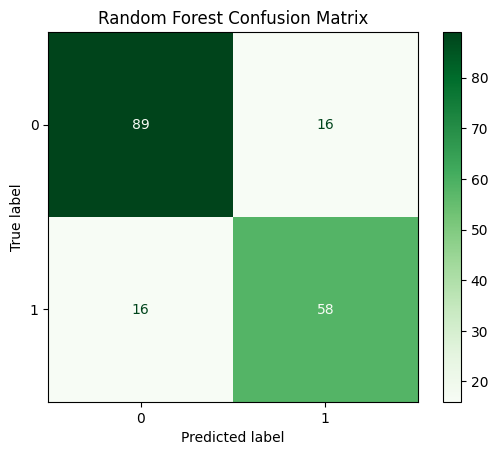

In [27]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

ConfusionMatrixDisplay(cm_lr).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm_rf).plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.798883
1,Random Forest,0.821229


## Observations

- The Titanic dataset contains **891 passenger records** with **12 attributes**.
- Missing values in the **Age** and **Embarked** columns were filled, while the **Cabin** column was removed due to a large number of missing values.
- A new feature called **FamilySize** was created to represent the total number of family members traveling together.
- The categorical features **Sex** and **Embarked** were converted into numerical values for model training.
- Exploratory Data Analysis showed that **gender**, **passenger class**, and **fare** had noticeable relationships with passenger survival.
- The Logistic Regression model achieved a testing accuracy of **79.89%**.
- The Random Forest model achieved a higher testing accuracy of **82.12%**.
- Based on the evaluation metrics and classification reports, the **Random Forest** model performed better and was selected as the final model for deployment.